<a href="https://colab.research.google.com/github/mzsmarcos/Analytics/blob/main/Analise_RFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Contexto**

Uma empresa do ramo de e-commerce precisa levantar os indicadores de recência, frequência e ticket médio (RFM) dos seus clientes.

A saber RFM:

- R (Recency): Tempo que o cliente realizou a última compra (em dias)
- F (Frequency): Quantidade de compras realizadas pelo cliente
- M (Monetary): Valor do ticket médio gasto pelo cliente

Onde ticket médio = média do total gasto por pedido para cada cliente.

Para isso, forneceu uma base de dados (arquivo csv) para que seja construído um código em Python que gera um output também csv, porém contendo apenas a identificação do cliente e métricas RFM.

In [ ]:
!pip install sidetable # facilita a análise exploratória de dados (EDA) ao fornecer resumos rápidos de tabelas, como contagem de valores, percentuais e identificação de valores ausentes.
!pip install ydata-profiling # antigo pandas-profiling uma ferramenta que gera relatórios automáticos para análise exploratória de dados.

In [ ]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import sidetable
from ydata_profiling import ProfileReport
import missingno as msno
from ipywidgets import interact, widgets

from sklearn import datasets
from sklearn.preprocessing import scale, minmax_scale, power_transform

In [ ]:
sns.set_theme(
    context='talk',
    style='ticks',
    font_scale=.8,
    rc={
        'figure.figsize': (12,8)
    }
)

In [ ]:
def list_attributes(obj):
  """Lista atributos e funções de um objeto"""
  return [attr for attr in obj.__dir__() if not attr.startswith('_')]

**Etapa 01)**  Leitura do arquivo e inspeção os dados

In [ ]:
!pip install chardet # biblioteca usada para detectar automaticamente a codificação de arquivos de texto

import chardet

# Detectar a codificação
with open('/content/data.csv', 'rb') as f:
    sample = f.read(20480)  # Lê os primeiros 20 KB
    result = chardet.detect(sample)

print(result)

{'encoding': 'ascii', 'confidence': 1.0, 'language': ''}


In [ ]:
df = pd.read_csv('/content/data.csv', encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.profile_report() # comando usado para gerar um relatório automático de análise exploratória de dados com a biblioteca ydata-profiling

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

**Etapa 02)** Remoção de valores faltantes na identificação do cliente

In [ ]:
# Identificar,  mostrar e somar valores nulos
df_missing = (
  df.isna().sum()
  .to_frame('missing_count')
  .join((df.isna().sum() / df.shape[0]).to_frame('missing_pct'))
  .sort_values('missing_count', ascending=False)
)

df_missing.style.format('{:.2%}', subset=['missing_pct'])

,missing_count,missing_pct
CustomerID,135080,24.93%
Description,1454,0.27%
InvoiceNo,0,0.00%
StockCode,0,0.00%
Quantity,0,0.00%
InvoiceDate,0,0.00%
UnitPrice,0,0.00%
Country,0,0.00%


In [ ]:
# Mostrando as linhas com valores faltantes como um todo:

df[df.isna().any(axis=1)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,12/9/2011 10:26,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,12/9/2011 10:26,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,12/9/2011 10:26,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,12/9/2011 10:26,10.79,NaN,United Kingdom


In [ ]:
# Mostrando as linhas com valores faltantes na coluna CustomerID

df[df.CustomerID.isna()]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,12/9/2011 10:26,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,12/9/2011 10:26,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,12/9/2011 10:26,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,12/9/2011 10:26,10.79,NaN,United Kingdom


In [ ]:
# Removendo valores faltantes na identificação do cliente

df = df.dropna(subset=['CustomerID'])
print(df.CustomerID.isna().sum()) # confirma se ainda existem valores ausentes na coluna

0


**Etapa 03)** Preços unitários e quantidade de produtos iguais ou
inferior a 0
1. Realize um filtro para verificar se existem dados nulos ou menor que zero na coluna
de preços
2. Filtre o dataset apenas para conter preços acima de zero
3. Realize um filtro para verificar se existem dados nulos ou menor que zero na coluna
de quantidade
4. Filtre o dataset apenas para conter quantidade acima de zero

In [ ]:
# Verificar valores nulos ou menores que zero em preços
print("Verificando preços nulos ou menores que zero:")
print(df[df['UnitPrice'].isnull() | (df['UnitPrice'] <= 0)])


Verificando preços nulos ou menores que zero:
       InvoiceNo StockCode                          Description  Quantity  \
9302      537197     22841         ROUND CAKE TIN VINTAGE GREEN         1   
33576     539263     22580         ADVENT CALENDAR GINGHAM SACK         4   
40089     539722     22423             REGENCY CAKESTAND 3 TIER        10   
47068     540372     22090              PAPER BUNTING RETROSPOT        24   
47070     540372     22553               PLASTERS IN TIN SKULLS        24   
56674     541109     22168        ORGANISER WOOD ANTIQUE WHITE          1   
86789     543599    84535B         FAIRY CAKES NOTEBOOK A6 SIZE        16   
130188    547417     22062  CERAMIC BOWL WITH LOVE HEART DESIGN        36   
139453    548318     22055   MINI CAKE STAND  HANGING STRAWBERY         5   
145208    548871     22162          HEART GARLAND RUSTIC PADDED         2   
157042    550188     22636   CHILDS BREAKFAST SET CIRCUS PARADE         1   
187613    553000     47566    

In [ ]:
# Filtrar o dataset
df = df[df['UnitPrice'] > 0]
print("Dataset após remoção de preços inválidos:")
print(df)


Dataset após remoção de preços inválidos:
       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPric

In [ ]:
# Verificar valores nulos ou menores que zero em quantidade
print("Verificando quantidade nula ou menor que zero:")
print(df[df['Quantity'].isnull() | (df['Quantity'] <= 0)])


Verificando quantidade nula ou menor que zero:
       InvoiceNo StockCode                       Description  Quantity  \
141      C536379         D                          Discount        -1   
154      C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235      C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236      C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237      C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   
...          ...       ...                               ...       ...   
540449   C581490     23144   ZINC T-LIGHT HOLDER STARS SMALL       -11   
541541   C581499         M                            Manual        -1   
541715   C581568     21258        VICTORIAN SEWING BOX LARGE        -5   
541716   C581569     84978  HANGING HEART JAR T-LIGHT HOLDER        -1   
541717   C581569     20979     36 PENCILS TUBE RED RETROSPOT        -5   

            InvoiceDate  UnitPrice  CustomerID         Country  

In [ ]:
# Filtrar o dataset
df = df[df['Quantity'] > 0]
print("Dataset após remoção de quantidades inválidas:")
print(df)


Dataset após remoção de quantidades inválidas:
       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  Uni

**Etapa 04)** Verifique se existem linhas duplicadas
1. Verifique se tem linhas duplicadas com a função duplicated
2. Drope as linhas duplicadas

In [ ]:
# Identificar valores duplicados
df[df.duplicated(keep=False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,12/9/2011 11:34,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,12/9/2011 11:34,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,12/9/2011 11:34,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,12/9/2011 11:34,2.10,14446.0,United Kingdom


In [ ]:
# Identificar quantos valores duplicados há em cada duplicata
(
  df
 .groupby(df.columns.tolist(), dropna=False)
 .size()
 .to_frame('n_duplicates')
 .query('n_duplicates>1')
 .sort_values('n_duplicates', ascending=False)
 .head(5)
)

n_duplicates
InvoiceNo StockCode Description                         Quantity InvoiceDate      UnitPrice CustomerID Country                     
555524    22698     PINK REGENCY TEACUP AND SAUCER      1        6/5/2011 11:37   2.95      16923.0    United Kingdom            20
          22697     GREEN REGENCY TEACUP AND SAUCER     1        6/5/2011 11:37   2.95      16923.0    United Kingdom            12
572861    22775     PURPLE DRAWERKNOB ACRYLIC EDWARDIAN 12       10/26/2011 12:46 1.25      14102.0    United Kingdom             8
541266    21755     LOVE BUILDING BLOCK WORD            1        1/16/2011 16:25  5.95      15673.0    United Kingdom             6
538514    21756     BATH BUILDING BLOCK WORD            1        12/12/2010 14:27 5.95      15044.0    United Kingdom             6

In [ ]:
#Remover valores duplicados
df.drop_duplicates()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


**Etapa 05)** Tipos de dados da coluna
1. Corrija o tipo de dado do CustomerID
2. Corrija o tipo de dado da InvoiceDate

Coluna        Tipo esperado
- InvoiceNo  :    object / str
- StockCode  :     object / str
- Description  :    object / str
- Quantity     :    int
- InvoiceDate  :     datetime
- UnitPrice    :     float
- CustomerID   :      int
- Country       :     object / str



In [ ]:
# Verificar os tipos dos dados que constam no dataset
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [ ]:
# Converte a coluna CustomerID para inteiro
df['CustomerID'] = df['CustomerID'].astype('int')

# Converte a coluna InvoiceDate para datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])



In [ ]:
# Verificar os tipos dos dados que constam no dataset após correção
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,int64
Country,object


**Etapa 06)** Tratando os outliers
Vamos considerar estes valores como erro. Visualize os outliers e remova os outliers extremos em que a quantidade do item na compra é superior a 10.000, e o preço unitário é maior que 5.000.

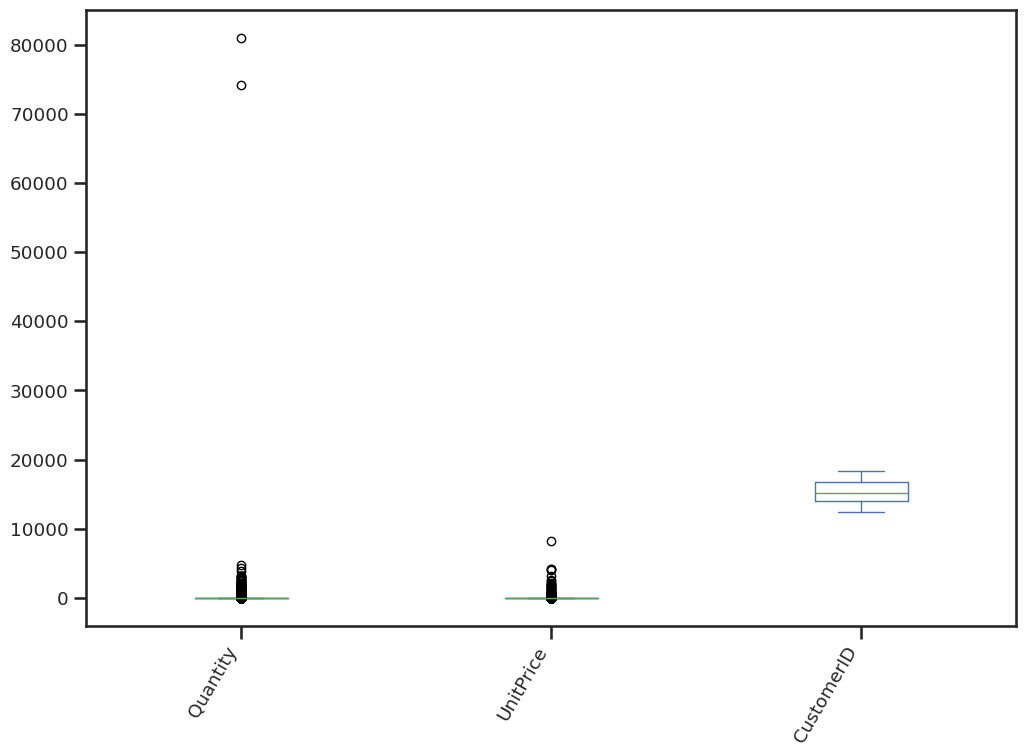

In [ ]:
# Visualizando outliers
df.plot.box()
plt.xticks(rotation=60, ha='right');

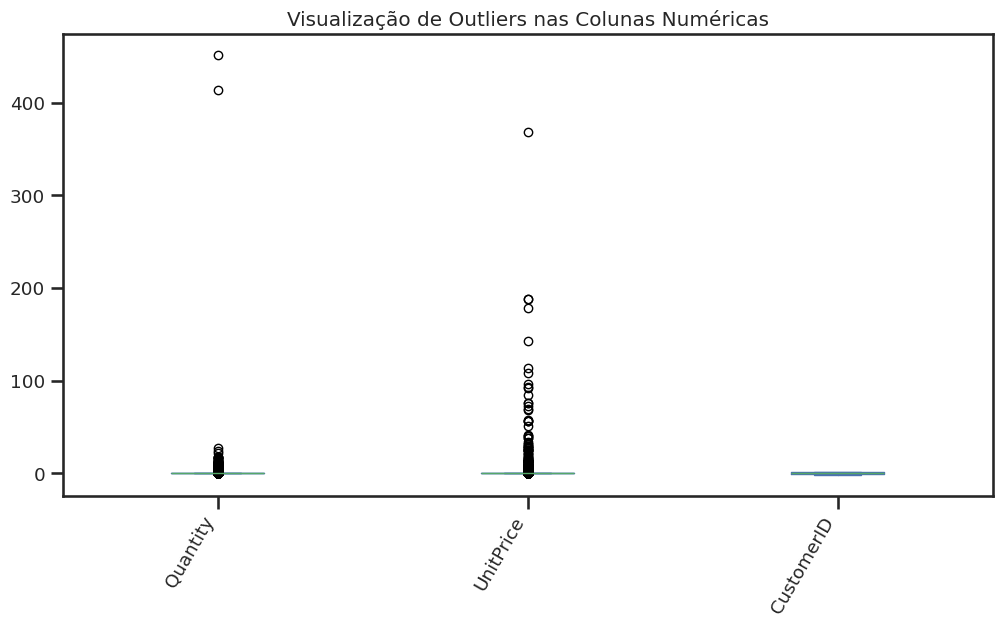

In [ ]:
# Selecionando apenas as colunas numéricas
numeric_columns = df.select_dtypes(include=['number'])

# Padronizando os dados numéricos
scaled_df = numeric_columns.apply(scale)

# Criando o boxplot para visualização dos outliers
scaled_df.plot.box(figsize=(12, 6))
plt.xticks(rotation=60, ha='right')
plt.title("Visualização de Outliers nas Colunas Numéricas")
plt.show()

In [ ]:
# Removendo os outliers extremos em que a quantidade do item na compra é superior a 10.000, e o preço unitário é maior que 5.000.

# Definindo os limites para remoção de outliers
quantity_threshold = 10000
unitprice_threshold = 5000

# Removendo as linhas com outliers extremos
df_filtered = df[(df['Quantity'] <= quantity_threshold) & (df['UnitPrice'] <= unitprice_threshold)]

# Exibindo o DataFrame sem os outliers
print(f"Shape antes da remoção: {df.shape}")
print(f"Shape depois da remoção: {df_filtered.shape}")


Shape antes da remoção: (397884, 8)
Shape depois da remoção: (397881, 8)


**Etapa 07)** Crie uma coluna adicional com o preço
total da compra

In [ ]:
df['TotalSale'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSale
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


**Etapa 08) Última data > data da última compra no dataset como um todo**

In [ ]:
# Identifica e define a última data de compra

last_data_sale = df['InvoiceDate'].max()

print(f"A última data de compra é: {last_data_sale}")

A última data de compra é: 2011-12-09 12:50:00


**Etapa 09) Plotando gráficos**

• Top 10 países com maior valor em vendas

• Top 10 produtos mais vendidos

• Valor de venda total por mês

• Valor de venda total por mês e por país (considere apenas os top 10)

In [ ]:
# Top 10 países com maior valor em vendas

import plotly.express as px

# 1. Agrupar por país e somar as vendas
total_vendas_por_pais = df.groupby('Country')['TotalSale'].sum()

# 2. Ordenar os países por vendas em ordem decrescente e pegar os 10 primeiros
top_10_paises = total_vendas_por_pais.sort_values(ascending=False).head(10).reset_index()

# 3. Criar o gráfico interativo de barras com Plotly Express
fig = px.bar(top_10_paises, x='Country', y='TotalSale',
             title='Top 10 Países por Valor de Vendas',
             labels={'TotalSale': 'Valor Total de Vendas'},  # Renomeia o rótulo do eixo y
             color='TotalSale',  # Adiciona cores às barras com base nos valores
             color_continuous_scale='viridis')  # Escolhe uma paleta de cores

# 4. Mostrar o gráfico
fig.show()



In [ ]:
# Top 10 produtos mais vendidos


# 1. Agrupar por país e somar as vendas
total_vendas_por_produtos = df.groupby('Description')['TotalSale'].sum()

# 2. Ordenar os produtos por vendas em ordem decrescente e pegar os 10 primeiros
top_10_produtos = total_vendas_por_produtos.sort_values(ascending=False).head(10).reset_index()

# 3. Criar o gráfico interativo de barras com Plotly Express
fig = px.bar(top_10_produtos, x='Description', y='TotalSale',
             title='Top 10 Produtos por Valor de Vendas',
             labels={'TotalSale': 'Valor Total de Vendas'},  # Renomeia o rótulo do eixo y
             color='TotalSale',  # Adiciona cores às barras com base nos valores
             color_continuous_scale='viridis')  # Escolhe uma paleta de cores

# 4. Mostrar o gráfico
fig.show()


In [ ]:
# Valor de venda total por mês

# 1. Extrair o mês e o ano da coluna 'InvoiceDate'
df['Mês'] = df['InvoiceDate'].dt.month
df['Ano'] = df['InvoiceDate'].dt.year

# 2. Agrupar por mês e ano e somar as vendas
total_vendas_por_mes = df.groupby(['Ano', 'Mês'])['TotalSale'].sum().reset_index()

# 3. Pivotear a tabela para o formato correto para o heatmap
total_vendas_pivot = total_vendas_por_mes.pivot(index='Ano', columns='Mês', values='TotalSale')

# 4. Criar o gráfico de calor com Plotly Express
fig = px.imshow(total_vendas_pivot,
             labels=dict(color='Total de Vendas'),  # Renomeia o rótulo da barra de cores
             title='Total de Vendas por Mês e Ano',
             color_continuous_scale='viridis')  # Escolhe uma paleta de cores

# 5. Formatar os rótulos dos eixos para melhor visualização
fig.update_layout(xaxis_title='Mês', yaxis_title='Ano')
fig.update_xaxes(tickvals=list(range(1, 13)), ticktext=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
                                                           'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

# 6. Mostrar o gráfico
fig.show()

In [ ]:
# Valor de venda total por mês e por país (considerando apenas os top 10)

# 5. Filtrar o DataFrame original para incluir apenas os top 10 países
df_top_10 = df[df['Country'].isin(top_10_paises['Country'])]

# 6. Agrupar por país, mês e ano e somar as vendas
total_vendas_mes_pais = df_top_10.groupby(['Ano', 'Mês', 'Country'])['TotalSale'].sum().reset_index()

# 7. Criar o gráfico de linha interativo com Plotly Express
fig = px.bar(total_vendas_mes_pais, x='Mês', y='TotalSale', color='Country',
             title='Valor de Vendas por Mês e País (Top 10)',
             labels={'TotalSale': 'Valor Total de Vendas'},  # Renomeia o rótulo do eixo y
             color_discrete_sequence=px.colors.qualitative.Set3)  # Escolhe uma paleta de cores

# 8. Formatar os rótulos dos eixos para melhor visualização
fig.update_layout(xaxis_title='Mês', yaxis_title='Valor Total de Vendas')
fig.update_xaxes(tickvals=list(range(1, 13)), ticktext=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
                                                           'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

# 9. Mostrar o gráfico
fig.show()



In [ ]:
# Valor de venda total por mês e por país com gráfico de área

fig = px.area(total_vendas_mes_pais, x='Mês', y='TotalSale', color='Country',
             title='Evolução das Vendas por Mês e País (Top 10)',
             labels={'TotalSale': 'Valor Total de Vendas'},
             color_discrete_sequence=px.colors.qualitative.Set3)  # Adicionado log_y=True

# 8. Formatar os rótulos dos eixos para melhor visualização
fig.update_layout(xaxis_title='Mês', yaxis_title='Valor Total de Vendas')
fig.update_xaxes(tickvals=list(range(1, 13)), ticktext=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
                                                           'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

# 9. Mostrar o gráfico
fig.show()



# **Etapa 10) Cálculo do RFM **

In [ ]:
# Agrupa por InvoiceNo e agrega as datas e o total do pedido
df_agrupado = df.groupby('InvoiceNo').agg(
    InvoiceDate=('InvoiceDate', 'unique'),  # Obtém datas únicas
    TotalSale=('TotalSale', 'sum')  # Soma os valores de TotalSale
).reset_index()

# Exibe o DataFrame resultante
print(df_agrupado)


      InvoiceNo            InvoiceDate  TotalSale
0        536365  [2010-12-01 08:26:00]     139.12
1        536366  [2010-12-01 08:28:00]      22.20
2        536367  [2010-12-01 08:34:00]     278.73
3        536368  [2010-12-01 08:34:00]      70.05
4        536369  [2010-12-01 08:35:00]      17.85
...         ...                    ...        ...
18527    581583  [2011-12-09 12:23:00]     124.60
18528    581584  [2011-12-09 12:25:00]     140.64
18529    581585  [2011-12-09 12:31:00]     329.05
18530    581586  [2011-12-09 12:49:00]     339.20
18531    581587  [2011-12-09 12:50:00]     249.45

[18532 rows x 3 columns]


In [ ]:
# Agrupamento apenas pos cliente e cálculo da Recência -  diferença em dias da última compra do cliente e da última compra disponível no conjunto de dados

# Agrupa por cliente e encontra a última data de compra
df_last_purchase = df.groupby('InvoiceNo')['InvoiceDate'].max().reset_index()

# Calcula a recência em dias
df_last_purchase['Recency'] = (last_data_sale - df_last_purchase['InvoiceDate']).dt.days

# Exibe o DataFrame resultante
print(df_last_purchase)

      InvoiceNo         InvoiceDate  Recency
0        536365 2010-12-01 08:26:00      373
1        536366 2010-12-01 08:28:00      373
2        536367 2010-12-01 08:34:00      373
3        536368 2010-12-01 08:34:00      373
4        536369 2010-12-01 08:35:00      373
...         ...                 ...      ...
18527    581583 2011-12-09 12:23:00        0
18528    581584 2011-12-09 12:25:00        0
18529    581585 2011-12-09 12:31:00        0
18530    581586 2011-12-09 12:49:00        0
18531    581587 2011-12-09 12:50:00        0

[18532 rows x 3 columns]


In [ ]:
# Cálculo da frequência - quantidade de compras feitas pelo cliente

# Agrupa por cliente e conta o número de compras
df_frequencia = df.groupby('InvoiceNo')['InvoiceNo'].count().reset_index(name='Frequencia')

# Exibe o DataFrame resultante
print(df_frequencia)

      InvoiceNo  Frequencia
0        536365           7
1        536366           2
2        536367          12
3        536368           4
4        536369           1
...         ...         ...
18527    581583           2
18528    581584           2
18529    581585          21
18530    581586           4
18531    581587          15

[18532 rows x 2 columns]


In [ ]:
# Cálculo do Ticket Médio - valor médio das compras feitas pelo cliente

# Agrupa por cliente e calcula a média do valor total das compras
df_ticket_medio = df.groupby('InvoiceNo')['TotalSale'].mean().reset_index(name='Ticket_Medio')

# Exibe o DataFrame resultante
print(df_ticket_medio)

      InvoiceNo  Ticket_Medio
0        536365     19.874286
1        536366     11.100000
2        536367     23.227500
3        536368     17.512500
4        536369     17.850000
...         ...           ...
18527    581583     62.300000
18528    581584     70.320000
18529    581585     15.669048
18530    581586     84.800000
18531    581587     16.630000

[18532 rows x 2 columns]


In [ ]:
# Dataframe original tratado

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSale,Mês,Ano
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,12,2010
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,2010
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,12,2010
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,2010
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,2010


In [ ]:
# Arquivo csv do dataframe original tratado

df.to_csv('df.csv', index=False) # gera o csv

from google.colab import files
files.download('df.csv') # faz o download do dataframe

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Dataframe de métricas do RFM

# Cria o DataFrame com as métricas
df_metricas_RFM = pd.concat([df_last_purchase['InvoiceNo'], df_last_purchase['Recency'],
                         df_frequencia['Frequencia'], df_ticket_medio['Ticket_Medio']], axis=1)

df_metricas_RFM.head()



,InvoiceNo,Recency,Frequencia,Ticket_Medio
0,536365,373,7,19.874286
1,536366,373,2,11.100000
2,536367,373,12,23.227500
3,536368,373,4,17.512500
4,536369,373,1,17.850000


In [ ]:
# Top 10 clientes com maior Ticket Médio

# Ordena o DataFrame pelo Ticket Médio em ordem decrescente e pega os 10 primeiros
top_10_clientes = df_metricas_RFM.sort_values('Ticket_Medio', ascending=False).head(10)

# Cria o gráfico de barras interativo com Plotly Express
fig = px.bar(top_10_clientes,
             x='InvoiceNo',
             y='Ticket_Medio',
             title='Top 10 Clientes por Ticket Médio',
             labels={'InvoiceNo': 'Código do Cliente',
                     'Ticket_Medio': 'Ticket Médio'})

# Personaliza o layout do gráfico (opcional)
fig.update_layout(xaxis_title='Código do Cliente',
                  yaxis_title='Ticket Médio',
                  title_x=0.5) # Centraliza o título

# Exibe o gráfico
fig.show()

In [ ]:
# Salva o DataFrame de métricas do RFM
df_metricas_RFM.to_csv('metricas_clientes.csv', index=False)

from google.colab import files
files.download('metricas_clientes.csv') # faz o download do dataframe de métricax


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>